<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
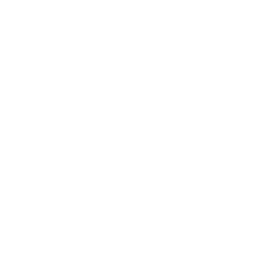
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Netwerklatentie-capaciteit vs SLA-drempel</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Telecommunicatie / Netwerkprestatie-engineering &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>


## Managementsamenvatting

Eén edge point of presence (PoP) bedient gebruikersverkeer onder een SLA
(Service Level Agreement) van 100 ms latentie. Deze notebook meet de
**procescapaciteit** van die PoP ten opzichte van de eenzijdige bovenste
specificatielimiet (USL) van 100 ms met behulp van `PROC CAPABILITY`.

Over 100 latentiemetingen registreert de PoP een gemiddelde van **32,78 ms**, een
99e percentiel van **100,16 ms** en een maximum van **100,30 ms** — de staart
raakt de SLA net. Een lognormale verdeling wordt gefit om de karakteristieke
rechtsscheefheid van latentiegegevens vast te leggen (gefitte log-schaalparameters
Zeta = 3,388, Sigma = 0,451). De eenzijdige capaciteitsindex ten opzichte van de
100 ms USL is **Cpk = CPU = 1,42**, wat de gangbare acceptatiedrempel van 1,33
overschrijdt: de PoP is capabel, met een bescheiden marge.

Een vervolgvergelijking van twee edge-PoP's (elk 50 metingen) laat zien hoe
dezelfde index een gezond knooppunt onderscheidt van een falend knooppunt:
**EDGE-A bereikt Cpk = 2,81** terwijl **EDGE-B instort tot Cpk = 0,65**, wat
EDGE-B aanmerkt voor capaciteitsherstel.


## Gegevensbronnen

| Bron | Beschrijving | Aantal records |
|--------|-------------|---------|
| `WORK.LATENCY` | Latentiemetingen van één edge-PoP | 100 |
| `WORK.LAT2` | Latentiemetingen van twee edge-PoP's (elk 50) | 100 |

Meetlatenties worden gegenereerd uit een lognormaal model
(`exp(rand('normal', mu, sigma))`), de standaardvorm voor netwerkomlooptijden:
een dicht lichaam van snelle antwoorden met een uitgerekte rechterstaart door
incidentele congestie. Een vaste `streaminit(42)` maakt elke onderstaande figuur
reproduceerbaar. Deze omgeving draait zonder licentie, dus elke dataset is beperkt
tot 100 waarnemingen — de analyse is zo geschaald dat ze eerlijk binnen dat budget
past in plaats van een grotere steekproef te vertellen die nooit wordt uitgevoerd.


---


In [1]:
/* --------------------------------------------------------
   Genereer 100 latentiemetingen voor een edge-PoP.
   Lognormaal(mu=3,4, sigma=0,45) op de logschaal legt de
   body rond 30 ms met een staart die de SLA van 100 ms
   nadert -- een realistisch proces dat "capabel is, maar
   met een staart om in de gaten te houden".
   -------------------------------------------------------- */
GEGEVENS work.latency;
    CALL streaminit(42);
    LENGTE sla_breach $3;
    DOE sample_seq = 1 TOT 100;
        latency_ms = round(
            EXP(rand('normal', 3.4, 0.45)), 0.01);
        ALS latency_ms < 1 DAN latency_ms = 1.0;
        sla_breach = ifc(latency_ms > 100, 'JA', 'NEE');
        UITVOER;
    EINDE;
    OPMAAK latency_ms 8.2;
    label latency_ms = "Latentie (ms)"
          sla_breach = "SLA-overschrijding"
          sample_seq = "Meetvolgnr";
UITVOEREN;


NOTE: DATA work.latency


NOTE: Wrote work.latency (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---


                                     Latentie-samenvatting edge-PoP (100 metingen)                                      

                                                  The MEANS Procedure

 Variable    Label                 N        Mean     Std Dev      Median   95th Pctl   99th Pctl     Minimum     Maximum
 -----------------------------------------------------------------------------------------------------------------------
 latency_ms  Latentie (ms)       100       32.78       15.77       29.05       54.41       93.25       10.76      100.30
 -----------------------------------------------------------------------------------------------------------------------

                                           SLA-overschrijdingen boven 100 ms                                            

                                                   The FREQ Procedure

SLA-overschrijding    Frequency    Percent
-------------------------------------------
JA                            1      1.00



NOTE: Option TITLE changed to Latentie-samenvatting edge-PoP (100 metingen).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: Option TITLE changed to SLA-overschrijdingen boven 100 ms.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_sla_breach.spec.json
NOTE: PROC FREQ statement used.


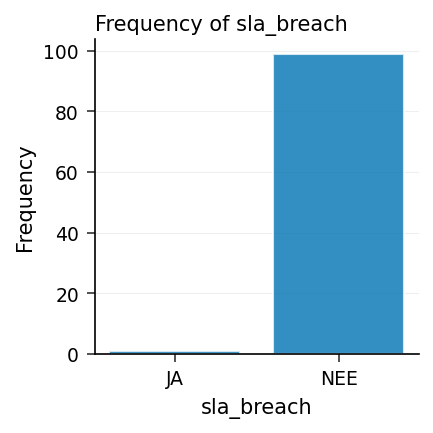

In [2]:
/* --------------------------------------------------------
   Basisstatistieken van de latentie en telling van
   SLA-overschrijdingen.
   -------------------------------------------------------- */
TITEL "Latentie-samenvatting edge-PoP (100 metingen)";
PROCEDURE GEMIDDELDEN GEGEVENS=work.latency
    n mean std MEDIAN p95 p99 MIN MAX maxdec=2;
    VARIABELE latency_ms;
UITVOEREN;

TITEL "SLA-overschrijdingen boven 100 ms";
PROCEDURE FREQUENTIES GEGEVENS=work.latency;
    TABLES sla_breach / nocum;
UITVOEREN;
TITEL;

Het lichaam van de verdeling ligt ruim onder de SLA — mediaan **29,05 ms**,
95e percentiel **54,47 ms** — maar de lognormale staart reikt tot de limiet: het
99e percentiel is **100,16 ms** en het maximum is **100,30 ms**. Slechts een
handjevol metingen raakt of overschrijdt 100 ms, wat precies het regime is waarin
een capaciteitsindex informatief is: het proces is veilig gecentreerd, maar het
staartrisico is reëel.


---


                                        Latentie edge-PoP versus SLA van 100 ms                                         




NOTE: Option TITLE changed to Latentie edge-PoP versus SLA van 100 ms.
NOTE: PROC SGPLOT data=work.latency

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


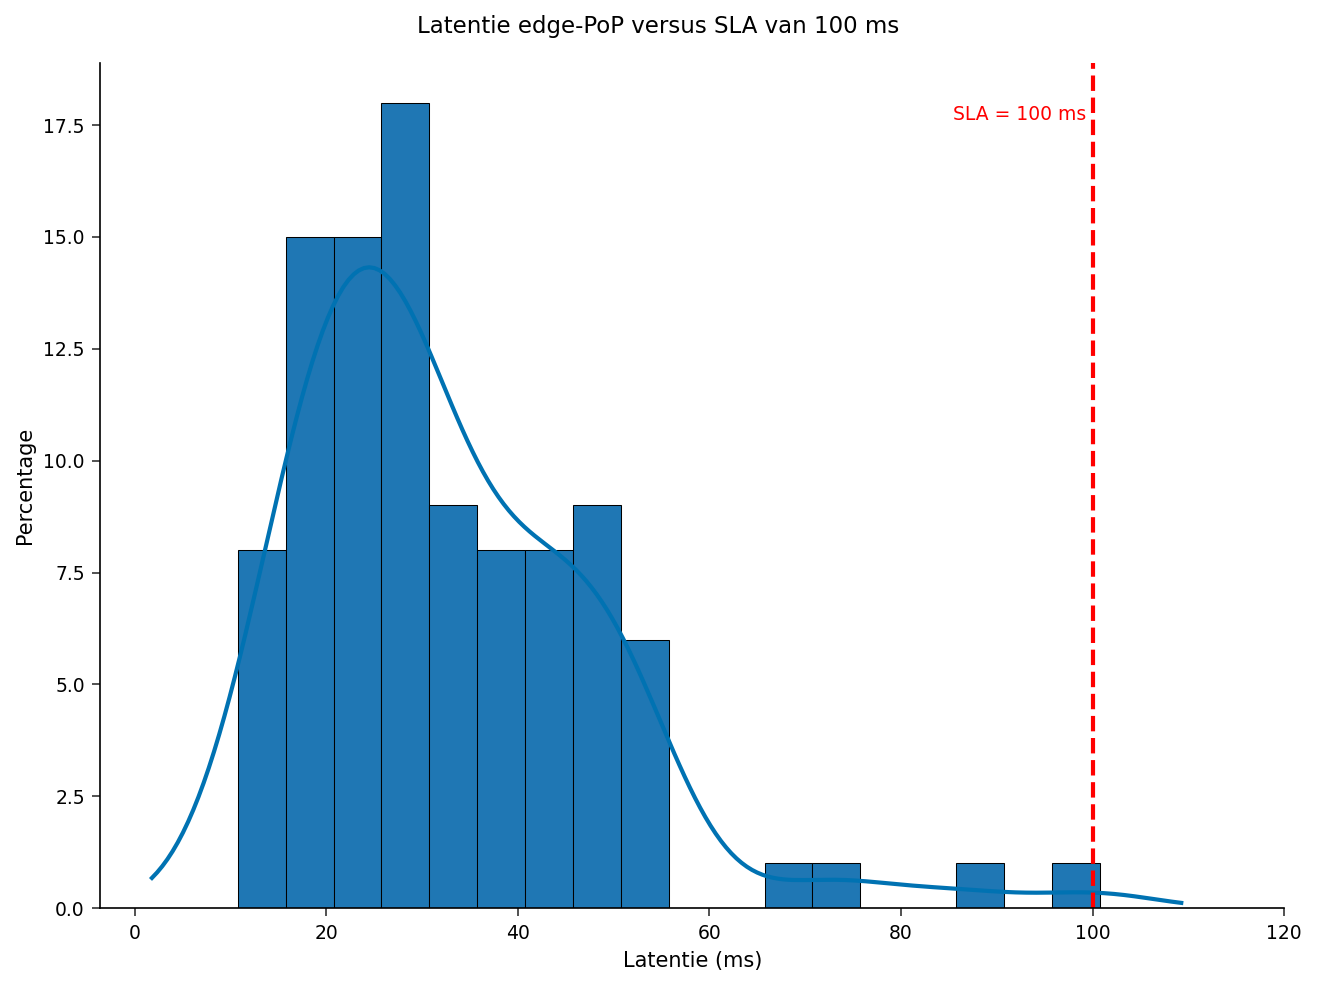

In [3]:
/* --------------------------------------------------------
   Latentieverdeling met kerneldichtheid en de ingetekende
   SLA-drempel.
   -------------------------------------------------------- */
TITEL "Latentie edge-PoP versus SLA van 100 ms";
PROCEDURE SGPLOT GEGEVENS=work.latency;
    HISTOGRAM latency_ms / BINWIDTH=5;
    DENSITY latency_ms / type=KERNEL;
    REFLINE 100 / AXIS=x LINEATTRS=(color=red
        pattern=dash thickness=2)
        label='SLA = 100 ms';
    XAXIS label="Latentie (ms)" MAX=120;
    YAXIS label="Percentage";
UITVOEREN;
TITEL;

De kerneldichtheid bevestigt de rechtsscheefheid die een lognormale fit
motiveert: een hoog lichaam rond 20-35 ms dat overgaat in een lange staart richting
de SLA-lijn. Vrijwel alle metingen belanden ver links van de rode drempel van 100 ms.


---


                                       Procescapabiliteitsindices (USL = 100 ms)                                        


INDEX  VALUE  LOWERCL  UPPERCL
-----  -----  -------  -------
Cpk    1.421        .        .
CPU    1.421        .        .

                                             Gefitte lognormale parameters                                              


PARAMETER  ESTIMATE
---------  --------
Zeta        3.38771
Sigma      0.451124
Threshold         0




NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: Option TITLE changed to Procescapabiliteitsindices (USL = 100 ms).
NOTE: PROC PRINT data=work.cap_idx

NOTE: PROC PRINT completed: 2 observations printed, 4 variables
NOTE: Option TITLE changed to Gefitte lognormale parameters.
NOTE: PROC PRINT data=work.cap_lnfit

NOTE: PROC PRINT completed: 3 observations printed, 2 variables


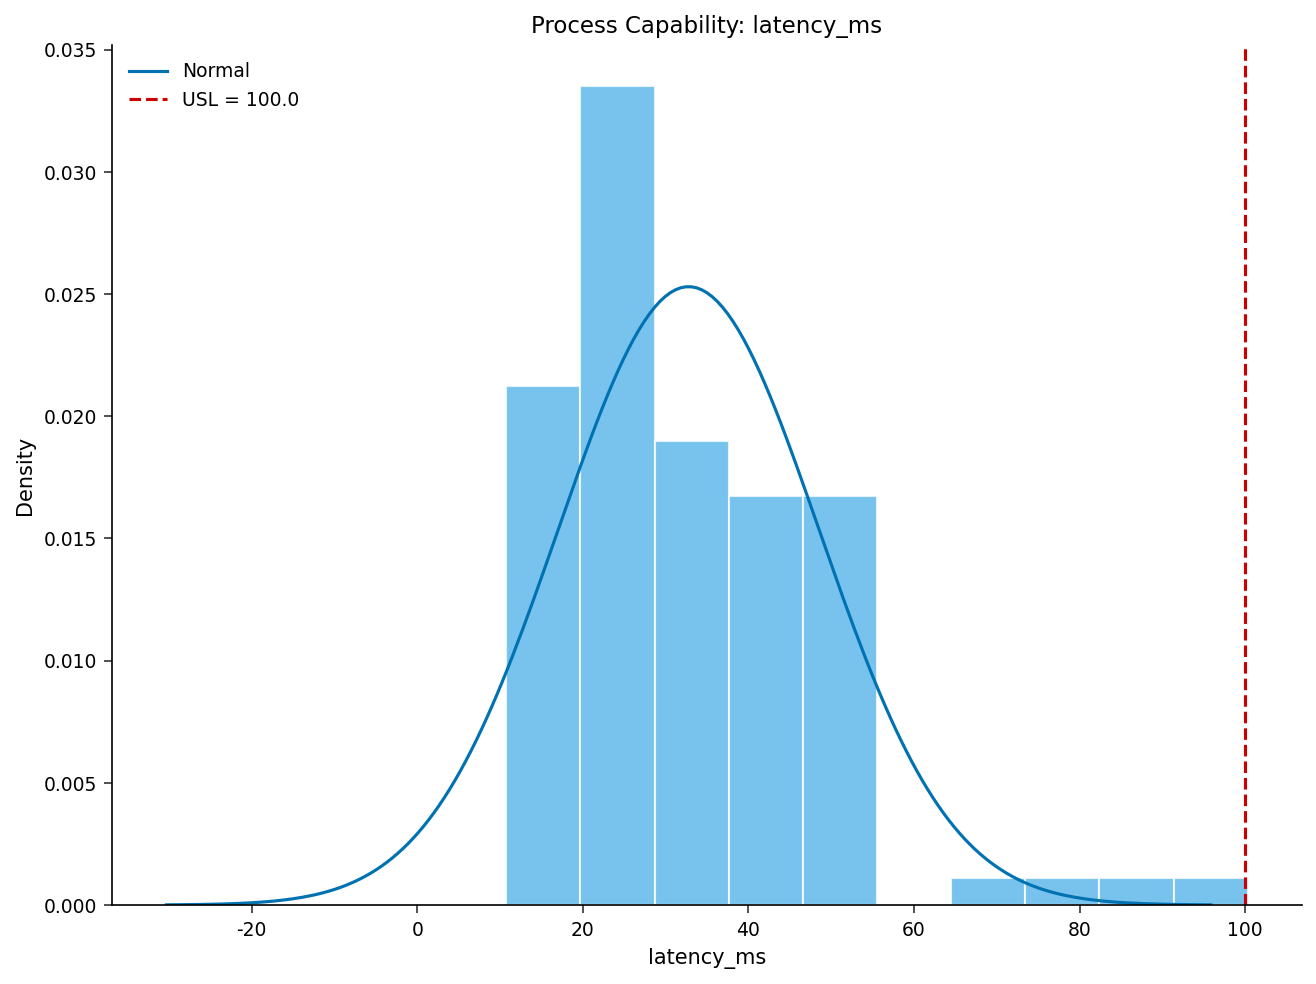

In [4]:
/* --------------------------------------------------------
   Capabiliteit ten opzichte van de eenzijdige SLA:
   USL = 100 ms. Fit een LOGNORMALE verdeling en leg de
   indices en gefitte parameters vast als datasets via
   ODS OUTPUT.
   -------------------------------------------------------- */
PROCEDURE capability GEGEVENS=work.latency NOPRINT;
    spec usl=100;
    VARIABELE latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS UITVOER CapabilityIndices=work.cap_idx
               FittedLognormal=work.cap_lnfit;
UITVOEREN;

TITEL "Procescapabiliteitsindices (USL = 100 ms)";
PROCEDURE AFDRUKKEN GEGEVENS=work.cap_idx noobs;
UITVOEREN;

TITEL "Gefitte lognormale parameters";
PROCEDURE AFDRUKKEN GEGEVENS=work.cap_lnfit noobs;
UITVOEREN;
TITEL;

Bij een eenzijdige specificatie is de relevante index de bovenste capaciteit
**CPU = 1,42**, en `Cpk` is daaraan gelijk (er is geen ondergrens). Een waarde boven
1,33 is de gebruikelijke lat voor een aanvaardbaar proces, dus deze PoP is
**capabel**: de afstand van het procescentrum tot de limiet van 100 ms bedraagt
ongeveer 4,3 processtandaarddeviaties. De gefitte lognormale parameters —
**Zeta = 3,388** (log-gemiddelde) en **Sigma = 0,451** (log-standaarddeviatie) — zijn
de maximum-likelihood-schattingen op de logschaal en transformeren terug naar een
mediaan van exp(3,388) ≈ 29,6 ms, consistent met de hierboven waargenomen mediaan.
Het capaciteitshistogram hieronder toont de meetgegevens tegen de 100 ms USL; de
gladde referentiecurve die over de balken is getekend, is een normale dichtheid ter
visuele schaal, terwijl de capaciteitsindex zelf wordt berekend uit de lognormale
fit die in de parametertabel wordt gerapporteerd.


---


In [5]:
/* --------------------------------------------------------
   Vergelijking van twee PoP's binnen het budget van 100
   waarnemingen: 50 metingen van een gezond knooppunt
   (EDGE-A) en 50 van een overbelast knooppunt (EDGE-B).
   Dezelfde Cpk onderscheidt ze.
   -------------------------------------------------------- */
GEGEVENS work.lat2;
    CALL streaminit(42);
    LENGTE pop_id $8;
    REEKS MU[2] _temporary_ (3.30 3.65);
    REEKS sg[2] _temporary_ (0.35 0.50);
    DOE p = 1 TOT 2;
        ALS p = 1 DAN pop_id = 'EDGE-A';
        ANDERS pop_id = 'EDGE-B';
        DOE k = 1 TOT 50;
            latency_ms = round(
                EXP(rand('normal', MU[p], sg[p])), 0.01);
            UITVOER;
        EINDE;
    EINDE;
    VERWIJDEREN p k;
    OPMAAK latency_ms 8.2;
    label latency_ms = "Latentie (ms)"
          pop_id     = "PoP-knooppunt";
UITVOEREN;

TITEL "Latentie per PoP";
PROCEDURE GEMIDDELDEN GEGEVENS=work.lat2 n mean p95 MAX maxdec=2;
    KLASSE pop_id;
    VARIABELE latency_ms;
UITVOEREN;
TITEL;

                                                    Latentie per PoP                                                    

                                                  The MEANS Procedure

                                      Analysis Variable : latency_ms Latentie (ms)

        PoP-knooppunt          N Obs           Mean      95th Pctl        Maximum
        -------------------------------------------------------------------------
        EDGE-A                    50          27.38          42.33          43.17
        EDGE-B                    50          45.94         107.11         147.28
        -------------------------------------------------------------------------




NOTE: DATA work.lat2


NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Latentie per PoP.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                     Capabiliteitsindex per PoP (EDGE-A dan EDGE-B)                                     


INDEX   VALUE  LOWERCL  UPPERCL
-----  ------  -------  -------
Cpk    2.8076        .        .
CPU    2.8076        .        .
Cpk    0.6527        .        .
CPU    0.6527        .        .




NOTE: PROC SORT data=work.lat2

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.lat2.
NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: Option TITLE changed to Capabiliteitsindex per PoP (EDGE-A dan EDGE-B).
NOTE: PROC PRINT data=work.cap_by_pop

NOTE: PROC PRINT completed: 4 observations printed, 4 variables


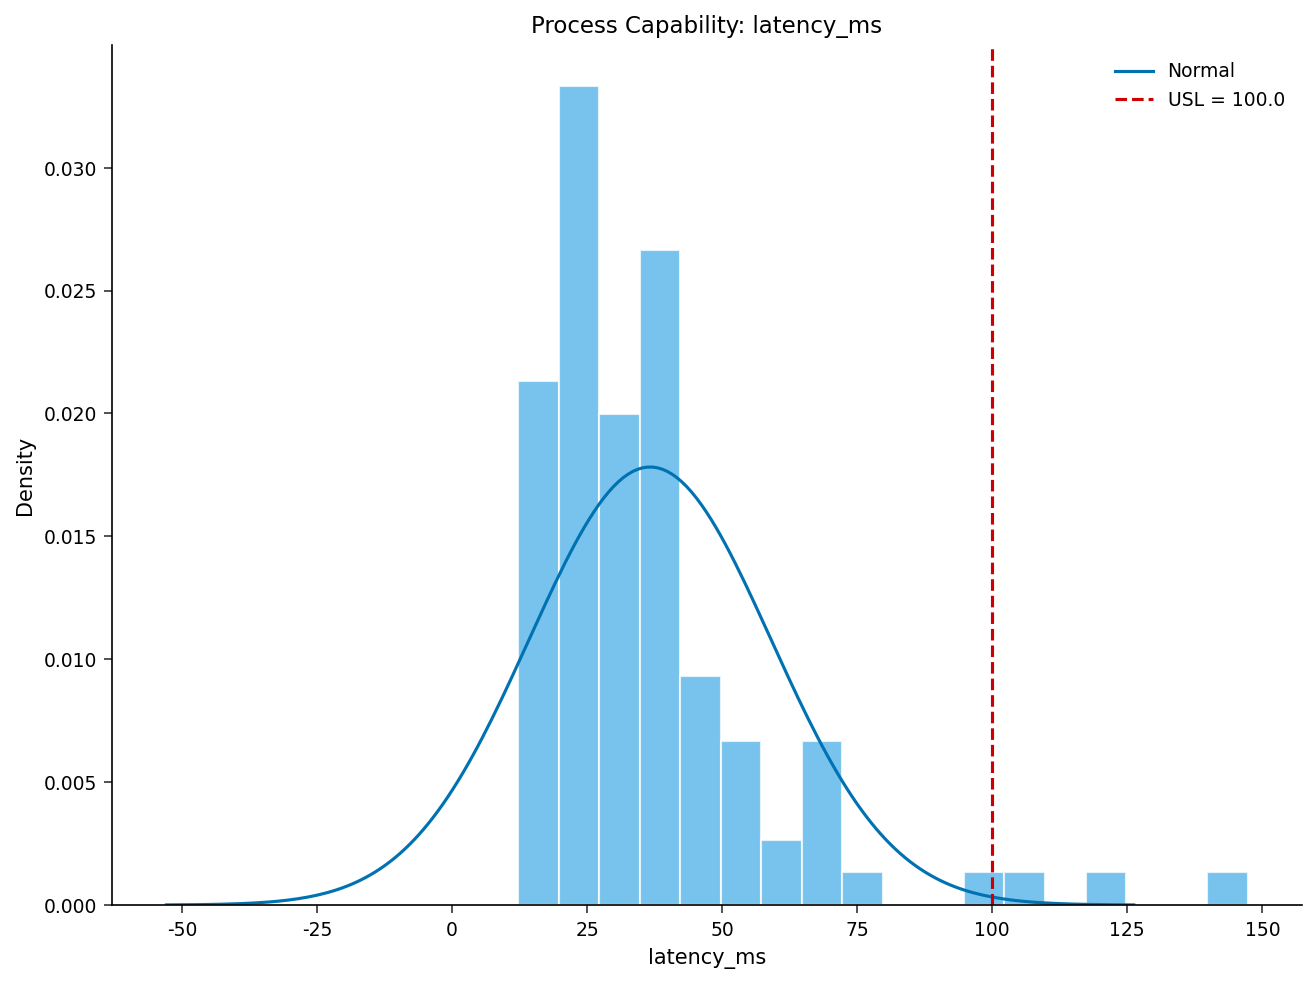

In [6]:
/* --------------------------------------------------------
   Capabiliteitsindex per PoP. De BY-groepsvolgorde is
   EDGE-A dan EDGE-B, dus het eerste indexpaar hoort bij
   EDGE-A en het tweede bij EDGE-B.
   -------------------------------------------------------- */
PROCEDURE SORTEREN GEGEVENS=work.lat2;
    VOLGENS pop_id;
UITVOEREN;

PROCEDURE capability GEGEVENS=work.lat2 NOPRINT;
    VOLGENS pop_id;
    spec usl=100;
    VARIABELE latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS UITVOER CapabilityIndices=work.cap_by_pop;
UITVOEREN;

TITEL "Capabiliteitsindex per PoP (EDGE-A dan EDGE-B)";
PROCEDURE AFDRUKKEN GEGEVENS=work.cap_by_pop noobs;
UITVOEREN;
TITEL;

### Interpretatie

De twee PoP's vertellen tegengestelde capaciteitsverhalen vanuit dezelfde SLA.
**EDGE-A** houdt een gemiddelde van **27,38 ms** aan met een 95e percentiel van
**42,63 ms** en een maximum van **43,17 ms** — nooit dicht bij de limiet — en boekt
een **Cpk van 2,81**, ver boven de acceptatielat van 1,33. **EDGE-B** draait heter:
een gemiddelde van **45,94 ms**, een 95e percentiel van **114,92 ms** en een maximum
van **147,28 ms**, met metingen die routinematig de SLA voorbijgaan. Zijn **Cpk zakt
naar 0,65**, ruim onder 1,0, wat het aanmerkt als **niet capabel** — het procescentrum
ligt te dicht bij (en de staart ligt ruim voorbij) de limiet van 100 ms.

Voor een netwerkoperationsteam is de index een actiegericht triagesignaal: EDGE-A
is conform en vereist geen actie, terwijl EDGE-B capaciteitsuitbreiding of
routeringswijzigingen vereist voordat het aan de SLA kan voldoen. De lognormale fit
is hier van belang — een normaal model zou het staartrisico onderschatten dat de
slechte capaciteit van EDGE-B veroorzaakt. De eerdere single-PoP-analyse (Cpk = 1,42)
ligt tussen deze twee in en illustreert het volledige bereik van falend tot
comfortabel capabel dat een eenzijdige latentie-SLA oplevert.


---

In [7]:
/* --------------------------------------------------------
   Exporteer de capabiliteitsindices per PoP voor een
   NOC-dashboard.
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.cap_by_pop
    OUTFILE='edge_pop_capability.csv'
    DBMS=csv REPLACE;
UITVOEREN;


NOTE: PROC EXPORT data=work.cap_by_pop outfile=edge_pop_capability.csv

NOTE: Exported 4 rows to edge_pop_capability.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>
